# Practice 1: PyTorch FashionMNIST Classification

## MLP vs CNN — Comparison

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Load Dataset | Download FashionMNIST + apply transforms | `src/data_utils.py` |
| 3 | Explore Dataset | Shape, class distribution, pixel stats | `src/vis_utils.py` |
| 4 | Create DataLoaders | Split into train/test batches | `src/data_utils.py` |
| 5 | Define Models | MLP (Linear) vs CNN (Conv2d) | — |
| 6 | Train Both Models | 10 epochs, log loss per epoch | `src/train_utils.py` |
| 7 | Compare: Loss Curves | Loss curves of MLP + CNN overlaid | `src/vis_utils.py` |
| 8 | Compare: Confusion Matrices | Per-class TPR/FPR/Precision + heatmaps | `src/eval_utils.py` |
| 9 | Compare: ROC Curves | Per-class ROC curves + AUC scores | `src/eval_utils.py` + `src/vis_utils.py` |v
| 10 | Compare: PR Curves | Per-class Precision-Recall curves + AP | `src/eval_utils.py` + `src/vis_utils.py` |
| 11 | Summary Table | Accuracy / ROC-AUC / PR-AUC / Params side-by-side | `src/eval_utils.py` |
| 12 | Save Models | Save .pth weights to `outputs/model/` | `src/model_utils.py` |
| 13 | Display Predictions | Predicted vs actual images for MLP + CNN | `src/vis_utils.py` |\n
| 14 | Misclassified Samples | Grid of wrong predictions (truth vs predicted) | `src/vis_utils.py` |\n

---

## 1. Import Libraries

Import `src/` utility modules, PyTorch core, and auto-detect device (MPS > CUDA > CPU).

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from src.data_utils import get_fashionmnist_transforms, load_fashionmnist, get_dataloaders
from src.vis_utils import explore_dataset, plot_losses, plot_confusion_matrix
from src.vis_utils import plot_roc_curves, plot_pr_curves, plot_predictions, plot_misclassified
from src.model_utils import save_model
from src.train_utils import train_model
from src.eval_utils import evaluate_detailed, get_all_probas_and_labels
from src.eval_utils import compute_roc_auc_scores, compute_pr_auc_scores, print_comparison_table

print(f"PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.8.0
Using device: mps


## 2. Load Dataset

Download FashionMNIST (60k train / 10k test) and normalize pixels to [-1, 1] with `ToTensor()` + `Normalize(0.5, 0.5)`.

In [2]:
transform = get_fashionmnist_transforms()
train_dataset, test_dataset = load_fashionmnist(transform)

## 3. Explore Dataset

Print basic info (classes, shape), show 10 sample images, class distribution bar chart, and pixel intensity histogram.

Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Train samples: 60000
Image shape: torch.Size([1, 28, 28])


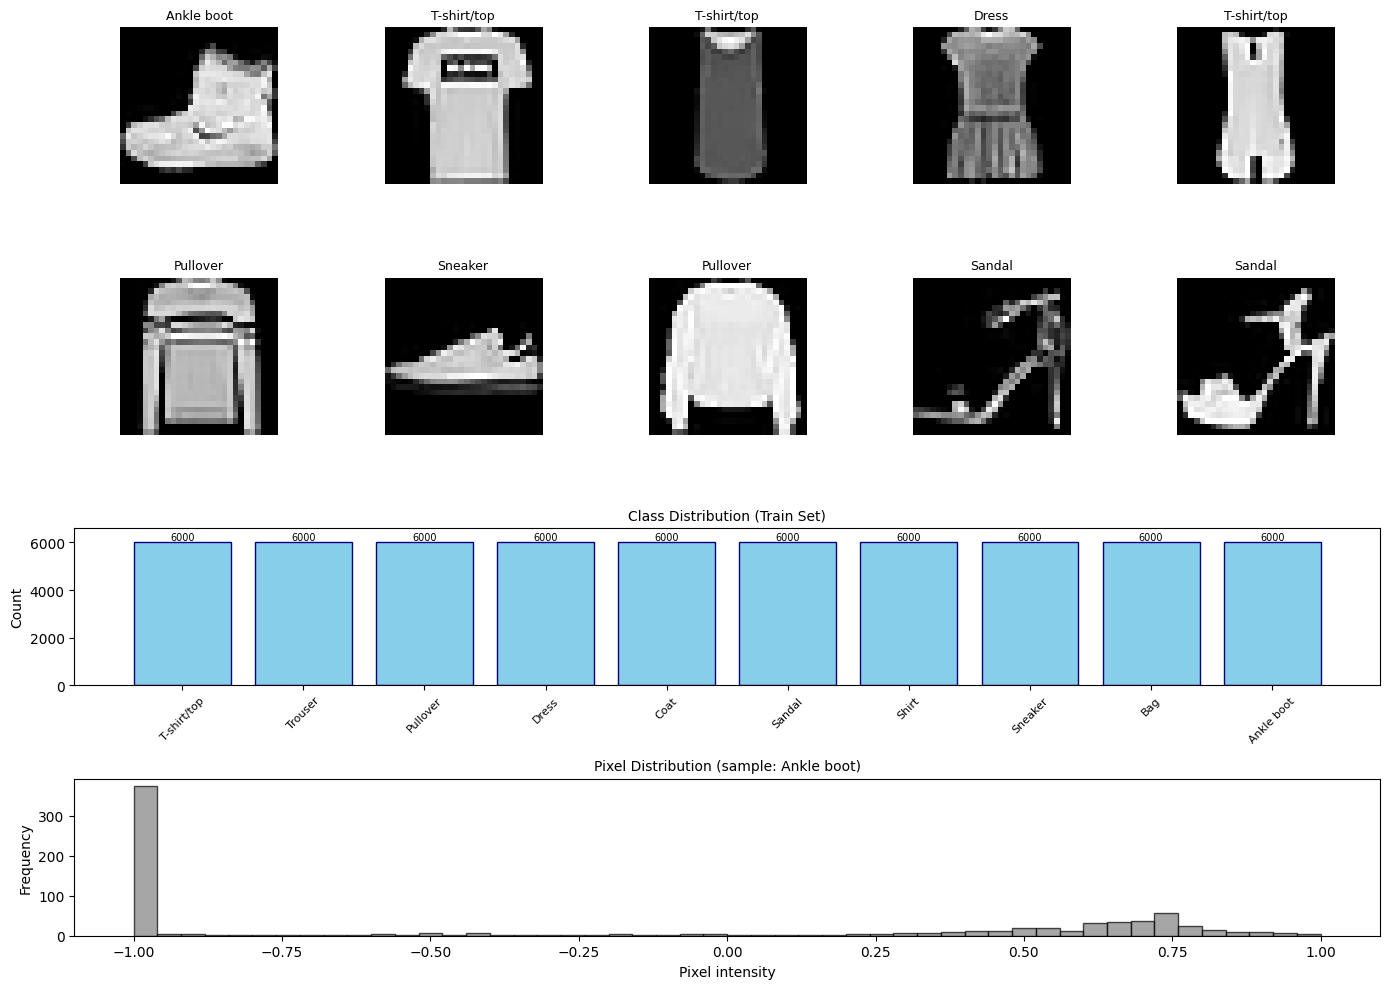

Image tensor shape: torch.Size([1, 28, 28])
Image tensor dtype: torch.float32
Pixel value range: [-1.0000, 1.0000]
Mean pixel value: -0.2372
Std pixel value: 0.7989


In [3]:
class_names = train_dataset.classes
explore_dataset(train_dataset, class_names)

## 4. Create DataLoaders

Batch size = 64. Train loader shuffles, test loader does not.

In [4]:
train_loader, test_loader = get_dataloaders(train_dataset, test_dataset, batch_size=64)
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 938
Test batches: 157


## 5. Define Models

**MLP:** `784 -> 256 -> 128 -> 10`, ReLU, Dropout(0.2).

**CNN:** `Conv2D(1->32) -> Pool -> Conv2D(32->64) -> Pool -> FC 128 -> 10`, ReLU, Dropout(0.25).

In [5]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_1=256, hidden_2=128, num_classes=10, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


model_mlp = MLP().to(device)
model_cnn = CNN().to(device)

mlp_params = sum(p.numel() for p in model_mlp.parameters())
cnn_params = sum(p.numel() for p in model_cnn.parameters())
print(f'MLP params: {mlp_params:,}')
print(f'CNN params: {cnn_params:,}')

MLP params: 235,146
CNN params: 421,642


## 6. Train Both Models

Both use `CrossEntropyLoss`, `Adam(lr=0.001)`, 10 epochs. `train_model` handles forward / backward / optimize loop.

In [6]:
criterion = nn.CrossEntropyLoss()
num_epochs = 40

print('--- Training MLP ---')
optimizer_mlp = optim.Adam(model_mlp.parameters(), lr=0.001)
train_losses_mlp = train_model(model_mlp, train_loader, criterion, optimizer_mlp, device, num_epochs)

print('\n--- Training CNN ---')
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)
train_losses_cnn = train_model(model_cnn, train_loader, criterion, optimizer_cnn, device, num_epochs)

--- Training MLP ---
Epoch [1/40], Loss: 0.5420
Epoch [2/40], Loss: 0.4110
Epoch [3/40], Loss: 0.3746
Epoch [4/40], Loss: 0.3553
Epoch [5/40], Loss: 0.3372
Epoch [6/40], Loss: 0.3255
Epoch [7/40], Loss: 0.3156
Epoch [8/40], Loss: 0.3057
Epoch [9/40], Loss: 0.2941
Epoch [10/40], Loss: 0.2890
Epoch [11/40], Loss: 0.2808
Epoch [12/40], Loss: 0.2740
Epoch [13/40], Loss: 0.2692
Epoch [14/40], Loss: 0.2618
Epoch [15/40], Loss: 0.2552
Epoch [16/40], Loss: 0.2517
Epoch [17/40], Loss: 0.2494
Epoch [18/40], Loss: 0.2417
Epoch [19/40], Loss: 0.2385
Epoch [20/40], Loss: 0.2335
Epoch [21/40], Loss: 0.2319
Epoch [22/40], Loss: 0.2288
Epoch [23/40], Loss: 0.2229
Epoch [24/40], Loss: 0.2195
Epoch [25/40], Loss: 0.2185
Epoch [26/40], Loss: 0.2153
Epoch [27/40], Loss: 0.2115
Epoch [28/40], Loss: 0.2078
Epoch [29/40], Loss: 0.2085
Epoch [30/40], Loss: 0.2019
Epoch [31/40], Loss: 0.2029
Epoch [32/40], Loss: 0.2011
Epoch [33/40], Loss: 0.1969
Epoch [34/40], Loss: 0.1933
Epoch [35/40], Loss: 0.1907
Epoch [3

## 7. Compare: Loss Curves

MLP (blue) vs CNN (orange) loss per epoch — CNN converges faster and reaches lower loss.

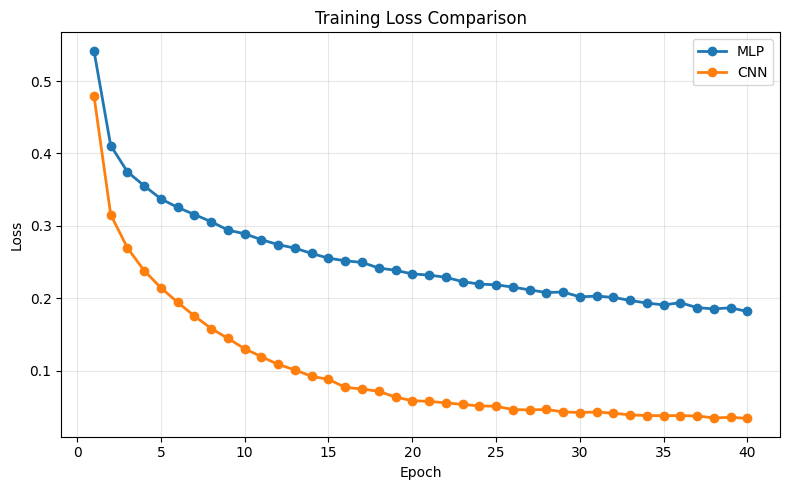

In [7]:
plot_losses({'MLP': train_losses_mlp, 'CNN': train_losses_cnn})

## 8. Compare: Confusion Matrices

Print accuracy, TPR (Recall), FPR, Precision per class + confusion matrix heatmaps for both models.

  Test Accuracy: 89.37%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8590     0.0200     0.8268
  Trouser             0.9660     0.0014     0.9867
  Pullover            0.8290     0.0172     0.8425
  Dress               0.9060     0.0142     0.8762
  Coat                0.8520     0.0201     0.8248
  Sandal              0.9580     0.0028     0.9746
  Shirt               0.6880     0.0271     0.7382
  Sneaker             0.9750     0.0099     0.9164
  Bag                 0.9650     0.0029     0.9738
  Ankle boot          0.9390     0.0024     0.9771


  Test Accuracy: 92.36%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8980     0.0183     0.8448
  Trouser             0.9810     0.0007     0.9939
  Pullover            0.9050     0.0143     0.8752
  Dress               0.9330     0.0110     0.9041
  Coat                0.8870     0.0

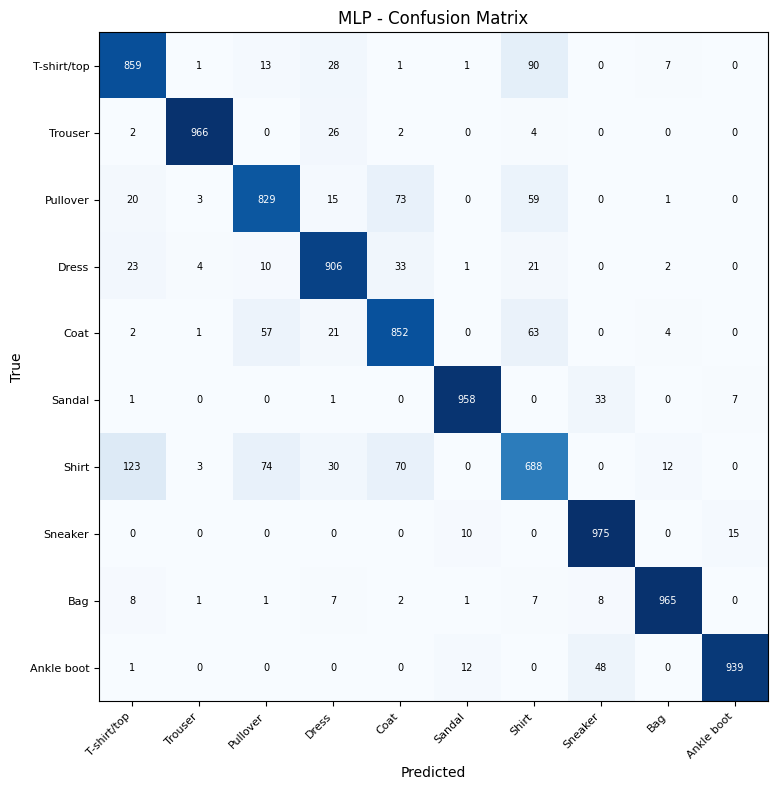

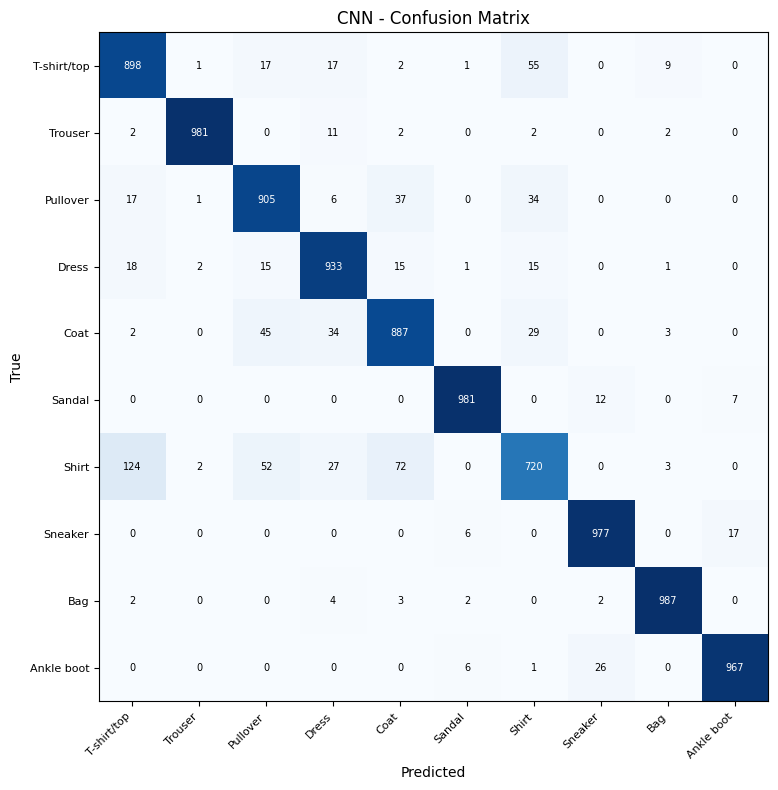

In [8]:
acc_mlp, cm_mlp, _ = evaluate_detailed(model_mlp, test_loader, device, class_names)
print('\n')
acc_cnn, cm_cnn, _ = evaluate_detailed(model_cnn, test_loader, device, class_names)

plot_confusion_matrix(cm_mlp, class_names, title='MLP - Confusion Matrix',
                      save_path='../outputs/plots/confusion_matrix_mlp.png')
plot_confusion_matrix(cm_cnn, class_names, title='CNN - Confusion Matrix',
                      save_path='../outputs/plots/confusion_matrix_cnn.png')

## 9. Compare: ROC Curves

Per-class ROC curves (10 subplots), each showing MLP vs CNN with AUC values. Macro AUC printed to console.

MLP macro ROC-AUC: 0.9917
CNN macro ROC-AUC: 0.9950


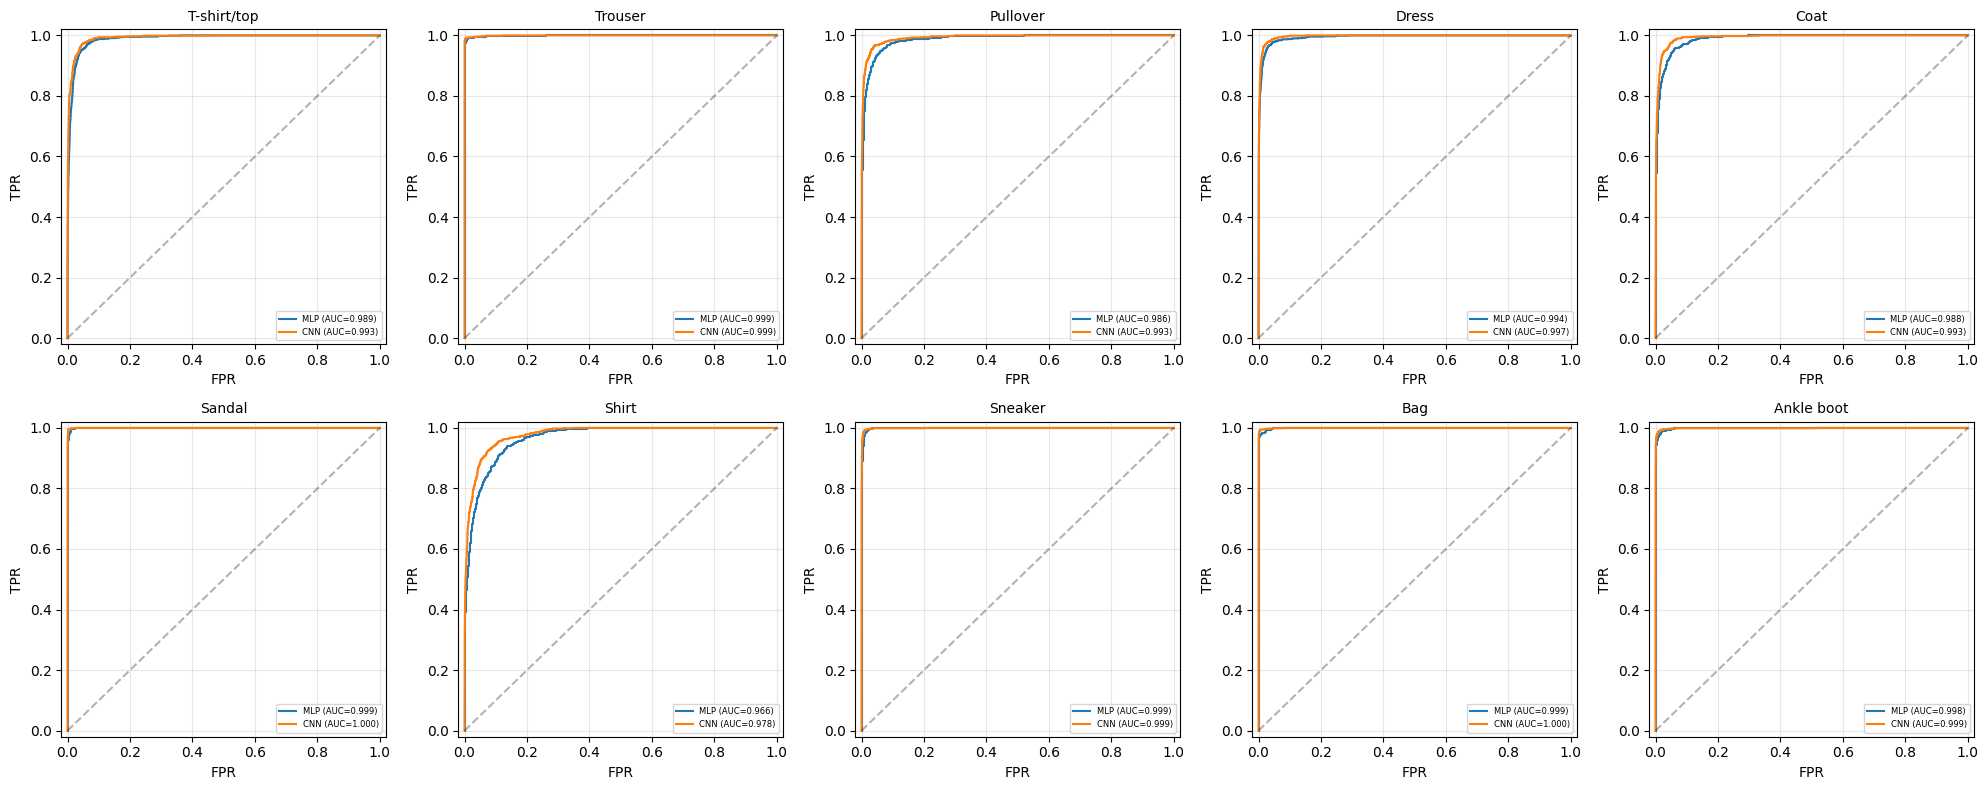

In [9]:
probas_mlp, labels = get_all_probas_and_labels(model_mlp, test_loader, device, 10)
probas_cnn, _ = get_all_probas_and_labels(model_cnn, test_loader, device, 10)

roc_mlp = compute_roc_auc_scores(probas_mlp, labels)
roc_cnn = compute_roc_auc_scores(probas_cnn, labels)

print(f'MLP macro ROC-AUC: {roc_mlp["macro"]:.4f}')
print(f'CNN macro ROC-AUC: {roc_cnn["macro"]:.4f}')

plot_roc_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 10. Compare: PR Curves

Per-class Precision-Recall curves (10 subplots), MLP vs CNN with AP (Average Precision) values.

MLP macro PR-AUC (AP): 0.9452
CNN macro PR-AUC (AP): 0.9642


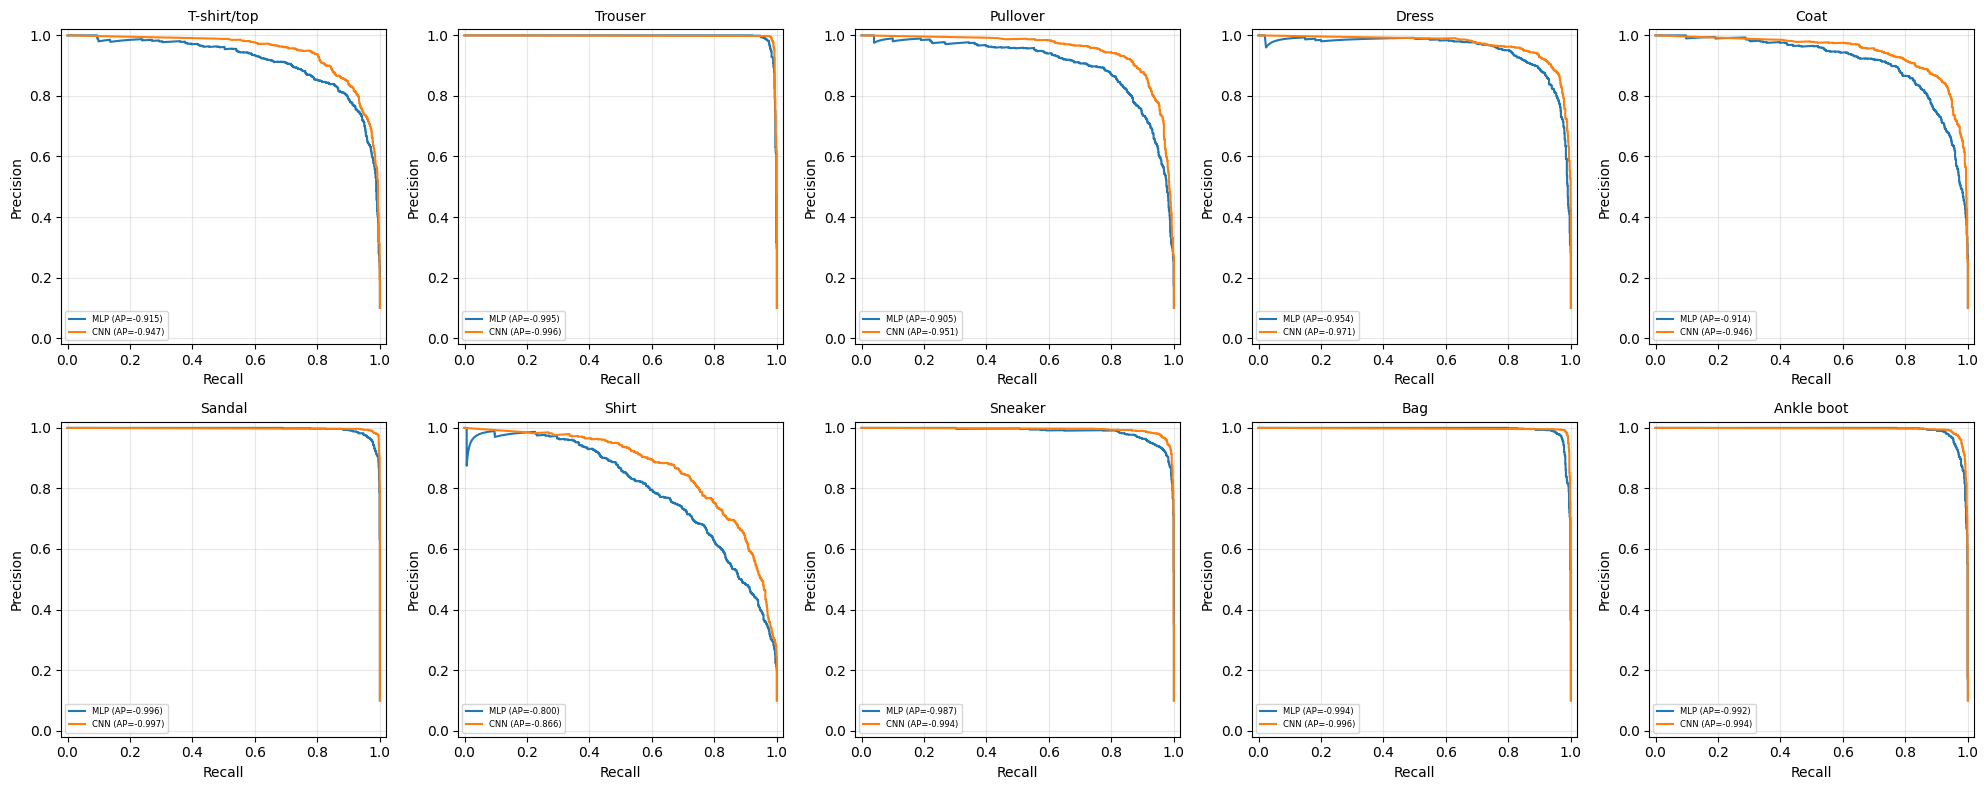

In [10]:
pr_mlp = compute_pr_auc_scores(probas_mlp, labels)
pr_cnn = compute_pr_auc_scores(probas_cnn, labels)

print(f'MLP macro PR-AUC (AP): {pr_mlp["macro"]:.4f}')
print(f'CNN macro PR-AUC (AP): {pr_cnn["macro"]:.4f}')

plot_pr_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 11. Summary Table

Compare Accuracy, ROC-AUC, PR-AUC (macro), and parameter count side-by-side, plus per-class breakdown.

In [11]:
print_comparison_table(acc_mlp, acc_cnn, roc_mlp, roc_cnn, pr_mlp, pr_cnn,
                       mlp_params, cnn_params, class_names)

Metric                             MLP          CNN         Diff
---------------------------------------------------------------------------
Test Accuracy (%)               89.37       92.36       +2.99
Macro ROC-AUC                  0.9917      0.9950     +0.0033
Macro PR-AUC (AP)              0.9452      0.9642     +0.0191
Parameters                    235,146     421,642    +186,496

Per-class ROC-AUC                  MLP          CNN
--------------------------------------------------
T-shirt/top                    0.9889      0.9926
Trouser                        0.9990      0.9995
Pullover                       0.9861      0.9925
Dress                          0.9939      0.9965
Coat                           0.9879      0.9931
Sandal                         0.9995      0.9997
Shirt                          0.9655      0.9783
Sneaker                        0.9986      0.9992
Bag                            0.9991      0.9995
Ankle boot                     0.9985      0.9989

Per-cl

## 12. Save Models

Save `.pth` weights to `outputs/model/` for future inference without retraining.

In [12]:
save_model(model_mlp, '../outputs/model/mlp_fashion_mnist.pth')
save_model(model_cnn, '../outputs/model/cnn_fashion_mnist.pth')

Model saved to ../outputs/model/mlp_fashion_mnist.pth
Model saved to ../outputs/model/cnn_fashion_mnist.pth


## 13. Display Predicted vs Actual Images

First batch of test set: green = correct, red = wrong. MLP and CNN side-by-side.

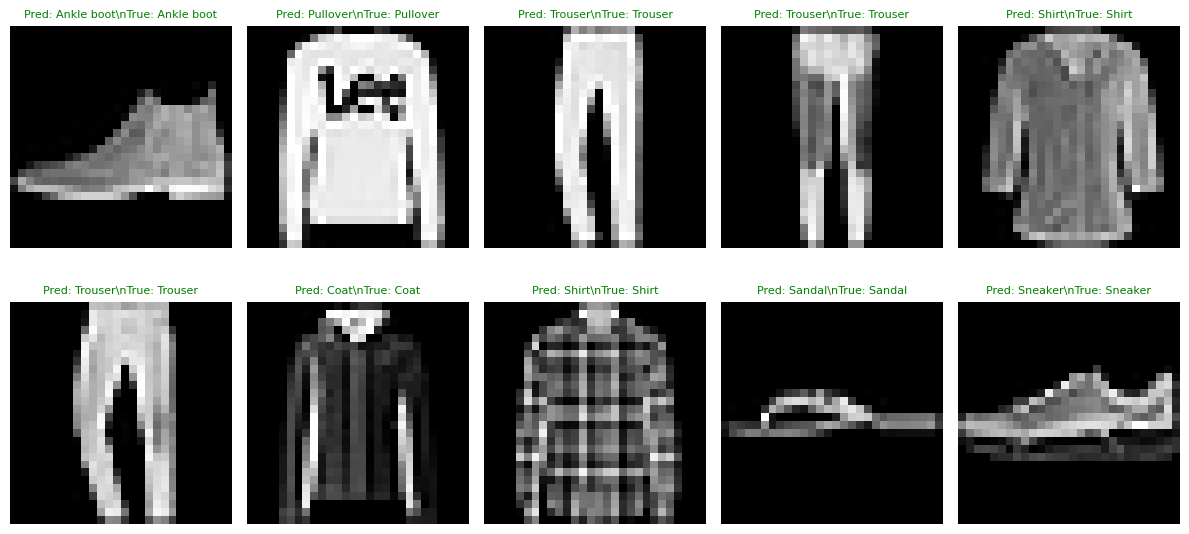

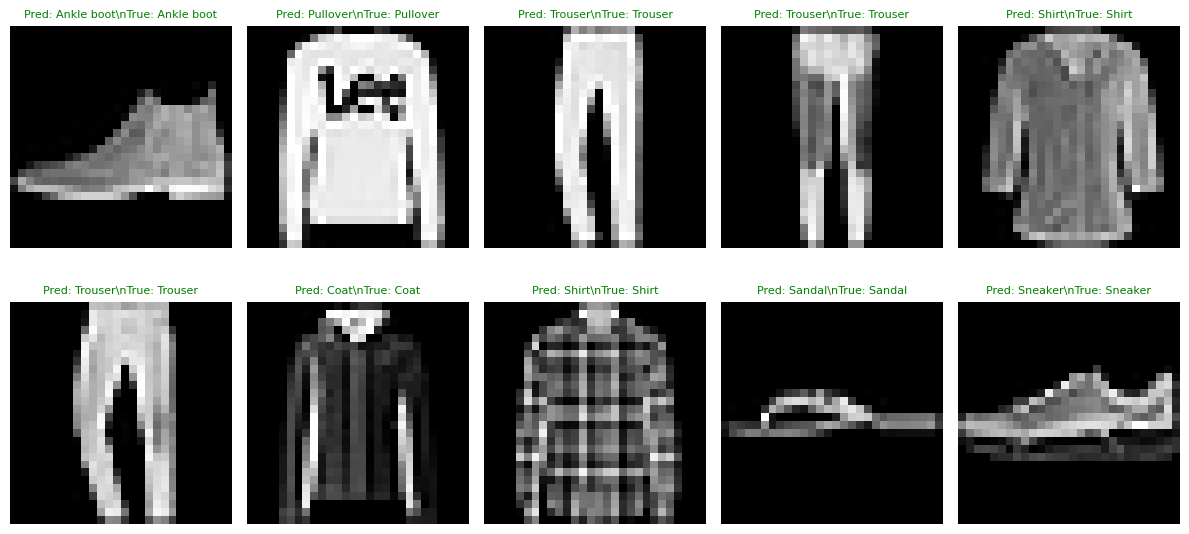

In [13]:
plot_predictions(model_mlp, test_loader, class_names, device,
               '../outputs/plots/predictions_mlp.png')
plot_predictions(model_cnn, test_loader, class_names, device,
               '../outputs/plots/predictions_cnn.png')

## 14. Misclassified Samples

Wrong predictions from first batch. True vs Predicted labels in red.

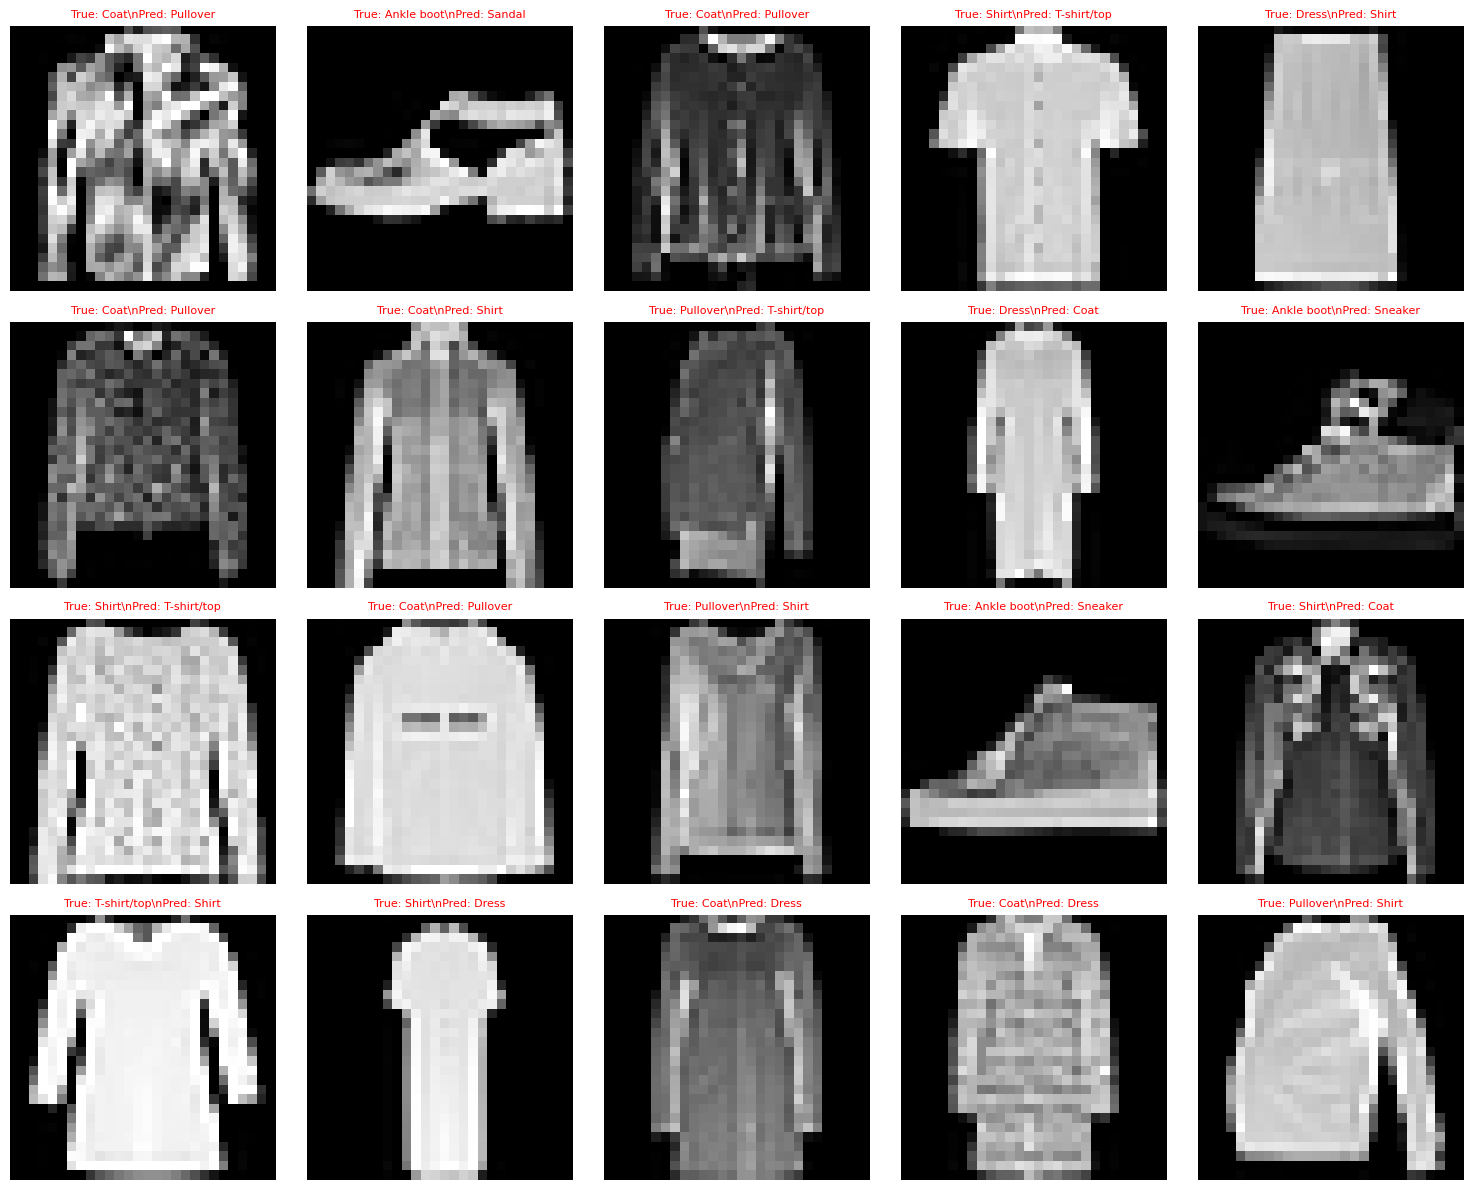

Displayed 20 misclassified samples.


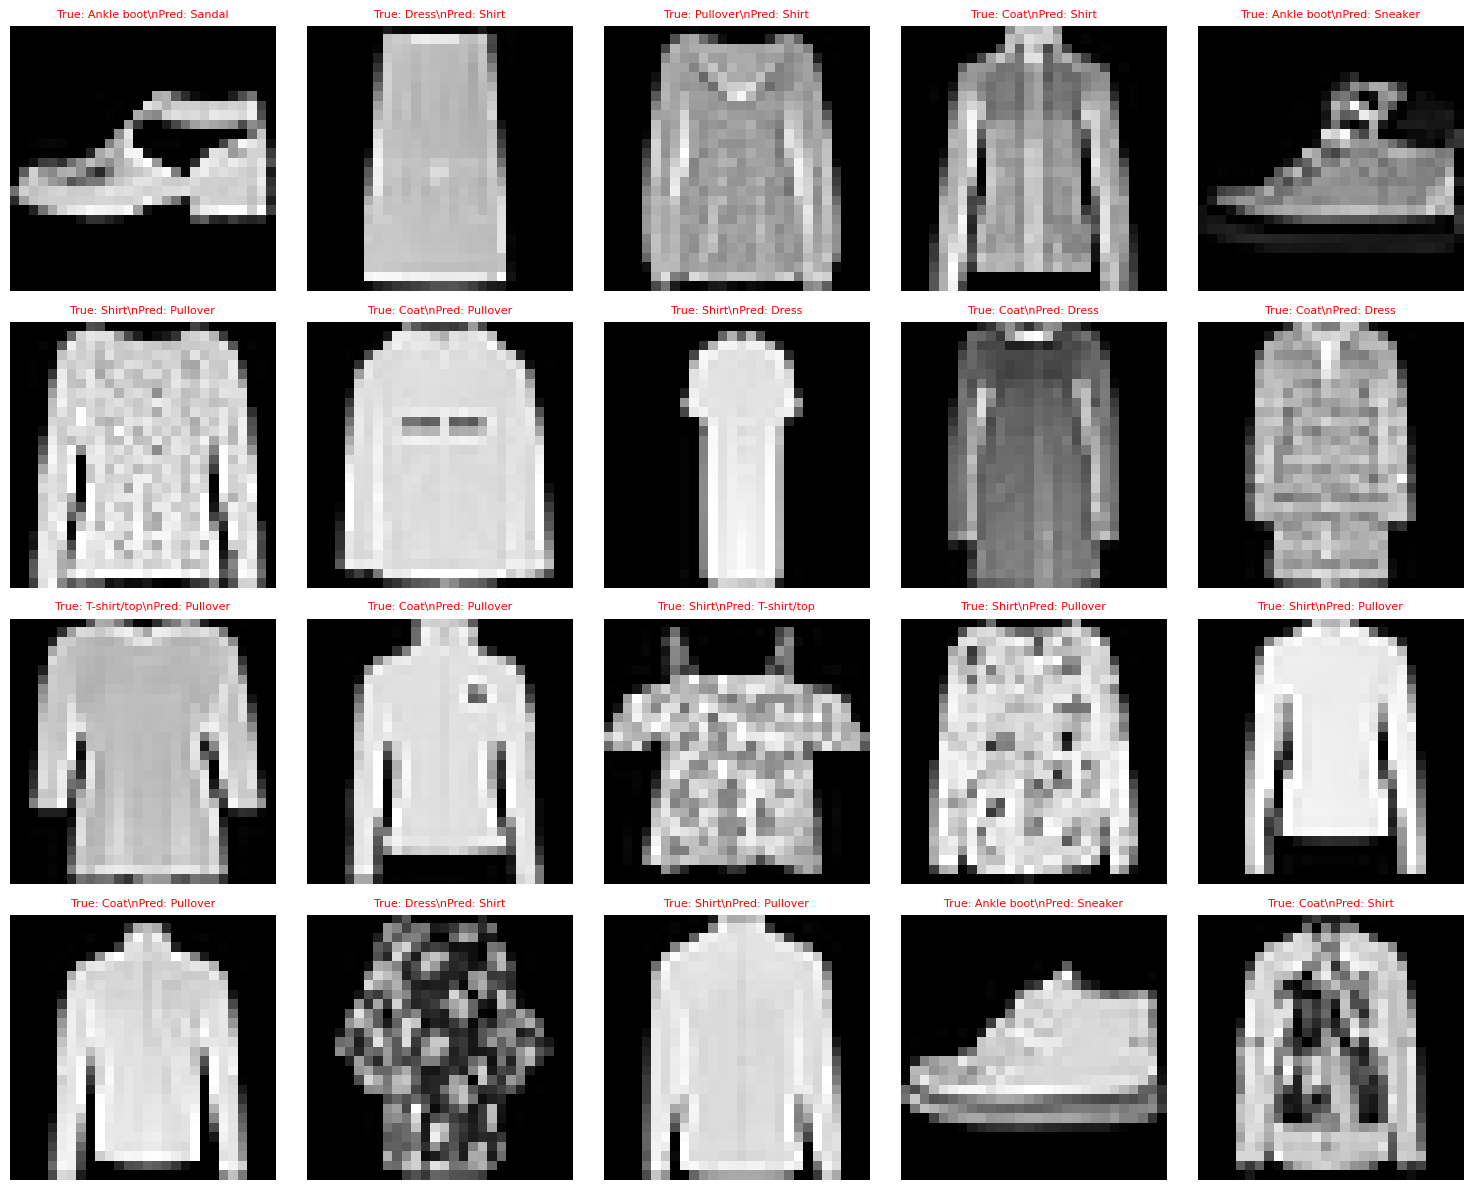

Displayed 20 misclassified samples.


In [14]:
plot_misclassified(model_mlp, test_loader, class_names, device, 20,
                   '../outputs/plots/misclassified_mlp.png')
plot_misclassified(model_cnn, test_loader, class_names, device, 20,
                   '../outputs/plots/misclassified_cnn.png')